In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
purchase = pd.read_csv("QVI_purchase_behaviour.csv")
transaction = pd.read_excel("QVI_transaction_data.xlsx")

In [ ]:
purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [47]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [48]:
purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [49]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [50]:
purchase.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [51]:
transaction.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [52]:
purchase = purchase.drop_duplicates()
transaction = transaction.drop_duplicates()

In [53]:
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,43464.036600,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,105.389336,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,43282.000000,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,43646.000000,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [54]:
transaction["PROD_QTY"].value_counts()

PROD_QTY
2      236038
1       27518
5         450
3         430
4         397
200         2
Name: count, dtype: int64

In [55]:
transaction["PROD_QTY"].describe()

count    264835.000000
mean          1.907308
std           0.643655
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [56]:
transaction = transaction[transaction["PROD_QTY"] < 10]

In [57]:
transaction["DATE"].head()

0    43390
1    43599
2    43605
3    43329
4    43330
Name: DATE, dtype: int64

In [58]:
transaction["DATE"] = pd.to_datetime(
    transaction["DATE"],
    origin="1899-12-30",
    unit="D"
)

In [59]:
transaction["PACK_SIZE"] = (
    transaction["PROD_NAME"]
    .str.extract(r'(\d+)')
    .astype(int)
)

In [60]:
transaction["BRAND"] = (
    transaction["PROD_NAME"]
    .str.split()
    .str[0]
)

In [61]:
data = transaction.merge(
    purchase,
    on="LYLTY_CARD_NBR"
)

In [62]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264833 entries, 0 to 264832
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264833 non-null  datetime64[ns]
 1   STORE_NBR         264833 non-null  int64         
 2   LYLTY_CARD_NBR    264833 non-null  int64         
 3   TXN_ID            264833 non-null  int64         
 4   PROD_NBR          264833 non-null  int64         
 5   PROD_NAME         264833 non-null  object        
 6   PROD_QTY          264833 non-null  int64         
 7   TOT_SALES         264833 non-null  float64       
 8   PACK_SIZE         264833 non-null  int64         
 9   BRAND             264833 non-null  object        
 10  LIFESTAGE         264833 non-null  object        
 11  PREMIUM_CUSTOMER  264833 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [64]:
data.groupby("LIFESTAGE")["TOT_SALES"].sum()

LIFESTAGE
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
OLDER FAMILIES            352467.20
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
Name: TOT_SALES, dtype: float64

In [65]:
data.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum()

PREMIUM_CUSTOMER
Budget        676211.55
Mainstream    750744.50
Premium       506152.95
Name: TOT_SALES, dtype: float64

In [66]:
data.groupby("LIFESTAGE")["TOT_SALES"].mean()

LIFESTAGE
MIDAGE SINGLES/COUPLES    7.357678
NEW FAMILIES              7.289124
OLDER FAMILIES            7.253307
OLDER SINGLES/COUPLES     7.386849
RETIREES                  7.364325
YOUNG FAMILIES            7.252709
YOUNG SINGLES/COUPLES     7.158515
Name: TOT_SALES, dtype: float64

In [67]:
data.groupby("LIFESTAGE")["PROD_QTY"].sum()

LIFESTAGE
MIDAGE SINGLES/COUPLES     47721
NEW FAMILIES               12847
OLDER FAMILIES             94592
OLDER SINGLES/COUPLES     104201
RETIREES                   94166
YOUNG FAMILIES             84561
YOUNG SINGLES/COUPLES      66634
Name: PROD_QTY, dtype: int64

In [68]:
data.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)

BRAND
Kettle        390239.8
Smiths        210070.8
Doritos       201538.9
Pringles      177655.5
Old            90785.1
Thins          88852.5
Twisties       81522.1
Tostitos       79789.6
Infuzions      76247.6
Cobs           70569.8
RRD            64954.5
Tyrrells       51647.4
Grain          43048.8
Cheezels       40029.9
Dorito         39052.0
WW             35889.5
Natural        34272.0
Red            30091.5
Infzns         22800.0
CCs            18078.9
Cheetos        16884.5
Smith          14583.4
Woolworths     13454.1
GrnWves         8568.4
NCC             8046.0
French          7929.0
Burger          6831.0
Snbts           5076.2
Sunbites        4600.2
Name: TOT_SALES, dtype: float64

In [69]:
data.groupby("PACK_SIZE")["TOT_SALES"].sum().sort_values(ascending=False)

PACK_SIZE
175    485431.4
150    304288.5
134    177655.5
110    162765.4
170    146673.0
330    136794.3
300    113330.6
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64

In [70]:
data.groupby("LYLTY_CARD_NBR").size()

LYLTY_CARD_NBR
1000       1
1002       1
1003       2
1004       1
1005       1
          ..
2370651    1
2370701    1
2370751    1
2370961    2
2373711    1
Length: 72636, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=data,
    x="LIFESTAGE",
    y="TOT_SALES",
    estimator=sum
)

plt.xticks(rotation=45)
plt.title("Total Sales by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")

plt.savefig("Lifestage_Sales.png", dpi=300, bbox_inches="tight")

plt.show()

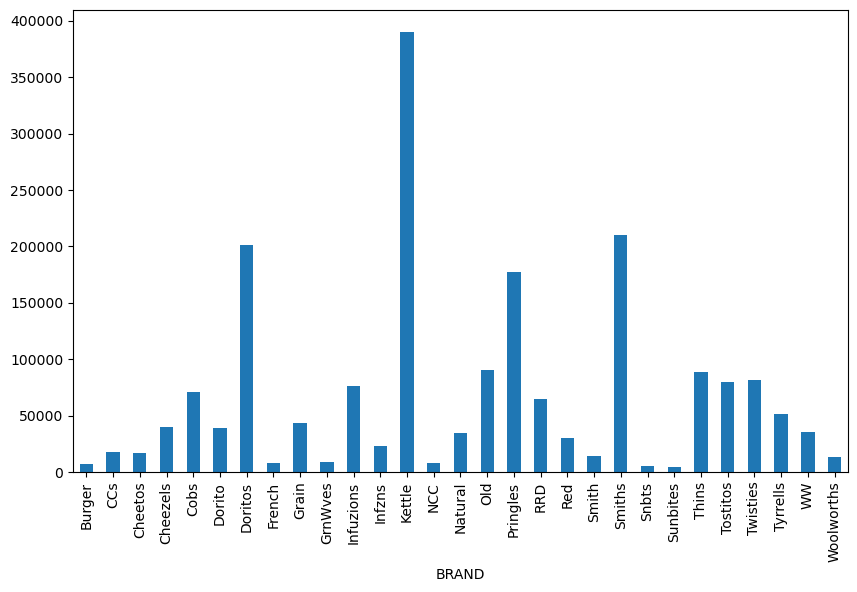

In [72]:
brand = data.groupby("BRAND")["TOT_SALES"].sum()

brand.plot(kind="bar", figsize=(10,6))

plt.show()

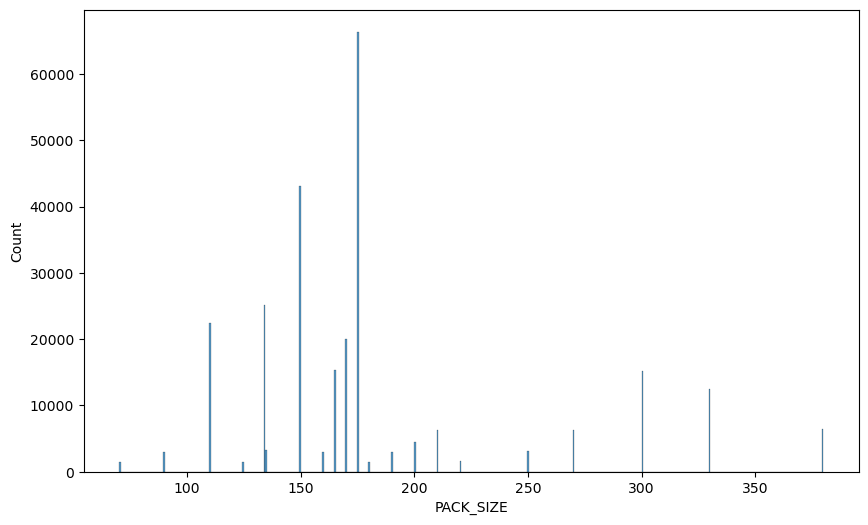

In [73]:
plt.figure(figsize=(10,6))

sns.histplot(data["PACK_SIZE"])

plt.show()